# Sprint 2b — ACS Time Series & Risk Scoring

## Changelog
| Version | Date | Author | Changes |
|---------|------|--------|---------|
| v1 | 2026-03-18 | Team | Initial build: 6-year ACS panel (2019-2024), per-tract trend slopes, 2027 risk projection, fragile tract flagging |
| v2 | 2026-03-19 | Claude | Dropped sklearn LinearRegression pipeline — notebook is strictly ACS time series (scipy.stats.linregress). Added setup cell with VS Code/Colab paths. Comprehensive sentinel cleaning across all numeric columns. Equity indicators CSV loaded to anchor fragile tract flagging to Sprint 2a equity_tier (replaces ad-hoc rescoring). Standardized to 4-tier system aligned with Sprint 2a. Dropped 3 redundant/broken pipeline cells. Fixed assign_status to use equity_tier. Removed mean_commute_time_min from profiling. Added numbered sections and markdown before every code cell. Added export cell with explicit output path. |

---

## Purpose & Role in the Final Solution

To understand where this notebook fits, it helps to see how the three analytical layers of this project relate to each other:

**Sprint 2a (Composite Equity Indicators)** answered: *where are we now?* It computed the current equity tier for every tract — Critical, High, Moderate, or Low — based on 7 indicators combining transit need and access deficit. That's a known, static fact about the current landscape.

**Sprint 2b (ML Model, covered in the feature engineering and modeling notebooks)** answers: *why, and what levers move the needle?* The ML model learns the relationships between features — headways, poverty rates, trend slopes, service span — and the equity score. Its value isn't telling us which tracts are inequitable (we already know that from Sprint 2a). Its value is enabling simulation: modify a service input, re-run the model, see how equity scores change. That's Sprint 3.

**This notebook** answers a third question: *where are things heading if nothing changes?* Using 6 years of ACS data (2019–2024), we calculate how fast key socioeconomic conditions are moving in each tract — poverty rising or falling, vehicle access improving or eroding — and project those trends forward to 2027. This gives us two outputs:

- **Worsening Tracts:** communities where poverty and vehicle access are both deteriorating simultaneously right now.
- **Fragile Tracts:** communities that don't look Critical today (per Sprint 2a) but are on a trajectory to get there by 2027 if conditions continue unchanged.

This matters for the simulation engine because it defines the stakes of inaction. When Sprint 3 runs scenarios — *what if we double evening frequency in these tracts?* — the time series analysis tells you which tracts are on a worsening path and therefore where intervening has the highest urgency. Without this, every simulation starts from a static 2024 snapshot. With it, you're comparing interventions against a future where some communities are actively deteriorating.

In Sprint 4, the fragile tract flags become the dashboard's early-warning layer — surfacing communities that need attention before they cross into crisis, not after.

**Data source:** ACS 5-Year Estimates, vintages 2019–2024, Miami-Dade County census tracts. The 2024 estimates were pulled specifically for this sprint to enable a full 6-year panel.


# 📊 Miami-Dade Socioeconomic Vulnerability Assessment (2019-2027)

### **Executive Summary**
This analysis identifies Census tracts in Miami-Dade County that are structurally degrading. By calculating the 6-year historical trajectory (2019-2024) of key socioeconomic features, we project these trends into the future to identify **"Fragile" tracts**—areas that currently appear moderately stable but are actively trending toward critical vulnerability.

---
## Step 1: Data Ingestion & Trend Engineering
First, we load the historical ACS data, clean Census artifacts (hidden nulls), and calculate the Annual Rate of Change (slope) for poverty and vehicle access.

### 📝 Note for the Team

Here is a quick breakdown of how this pipeline was constructed:

1. **Data Ingestion & Cleaning:** We load the 6-year ACS panel (2019–2024) and replace Census null artifacts (like `-666666666`) with `NaN` before any computation. This is the same sentinel-cleaning step used in the feature engineering notebook.

2. **Trend Slope Computation:** For each tract and each ACS variable, we fit a linear regression across the 6 yearly observations using `scipy.stats.linregress`. The slope tells us the annual rate of change — e.g., poverty rising 0.4 percentage points per year. We require at least 2 data points to compute a slope; tracts with fewer are assigned `NaN`.

3. **2027 Projection:** We extrapolate each tract's poverty rate and vehicle access 3 years forward using the formula `projected = current + (slope × 3)`. Values are clipped to [0, 100]. This is a linear extrapolation, not a predictive ML model — it assumes current trends continue unchanged, which is the right framing for an early-warning flag.

4. **Equity Anchoring:** We load the Sprint 2a equity indicators to get each tract's current `equity_tier` (Critical / High / Moderate / Low). This replaces any ad-hoc rescoring — the Sprint 2a tiers are the authoritative baseline for where tracts stand today.

5. **Flagging Fragile Tracts:** A tract is flagged as **Fragile** if it is currently Moderate or High (not yet Critical per Sprint 2a) but its trend projection puts it in Critical territory by 2027. A tract is flagged as **Worsening** if both its poverty slope and its no-vehicle slope are positive simultaneously.

6. **Deep Dive:** We profile flagged tracts against stable and already-Critical tracts using underlying stressors (rent burden, uninsured rates, unemployment, income trajectory) to characterize what drives the degradation.


### 2b.6 — Risk Scoring and Time Series Findings

**Objective:**
1. **Trend Computation:** Compute per-tract annual rate of change (linear slope via `scipy.stats.linregress`) for key ACS variables across the 2019–2024 panel.
2. **Forward Projection:** Extrapolate poverty rate and vehicle access 3 years forward to 2027 using each tract's own trend slope.
3. **Equity Anchoring:** Load Sprint 2a equity tiers as the current baseline — no parallel scoring system.
4. **Vulnerability Flagging:**
   - **Worsening Trends:** Poverty slope > 0 AND no-vehicle slope > 0 simultaneously.
   - **Fragile Tracts:** Currently Moderate or High (Sprint 2a tier), projected to cross into Critical by 2027.


## 1. Setup

File paths and imports. If running locally in VS Code, the paths below point to the project folder structure.
If running on Google Colab, comment out the local paths and uncomment the Colab equivalents.

In [3]:
# --- File Paths ---
# Local (VS Code) — absolute path to the Deloitte Capstone project root on your machine
BASE        = '/Users/lunagerlicsantoni/Desktop/Spring Classes/Deloitte Capstone'
ACS_DIR     = f'{BASE}/Sprint 2 /ACS Tract Level Data'
EQUITY_PATH = f'{BASE}/Sprint 2 /Composite Equity Indicators/Sprint2_Equity_Indicators_v3_tract.csv'
OUTPUT_PATH = f'{BASE}/Sprint 2 /Sprint2b_Tract_Risk_Projections.csv'

# Google Colab — uncomment below and comment out the four lines above
# BASE        = '/content'
# ACS_DIR     = '/content'
# EQUITY_PATH = '/content/Sprint2_Equity_Indicators_v3_tract.csv'
# OUTPUT_PATH = '/content/Sprint2b_Tract_Risk_Projections.csv'


## 2. Data Loading & Cleaning

Load all 6 ACS vintages (2019–2024) into a single stacked panel dataframe. Census API returns sentinel values (e.g. `-666666666`, `-222222222`) for missing estimates — these are valid integers that won't be caught by standard null checks, so we replace them with `NaN` across all numeric columns before any computation.

**Expected output:** a panel of ~4,200 rows (6 years × ~700 tracts) with all sentinel values replaced.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
import warnings
warnings.filterwarnings('ignore')

# Load 6 ACS vintages into a stacked panel
YEARS = [2019, 2020, 2021, 2022, 2023, 2024]

df_history = pd.concat(
    [pd.read_csv(f'{ACS_DIR}/ACS_MiamiDade_Tracts_{y}.csv').assign(Year=y) for y in YEARS],
    ignore_index=True
)
# df_history = pd.concat(
#     [pd.read_csv(f'{ACS_DIR}/ACS_MiamiDade_Tracts_{y}.csv').assign(Year=y) for y in YEARS],
#     ignore_index=True
# )  # Colab — update ACS_DIR to '/content' in the setup cell above

# Replace all Census sentinel values with NaN across every numeric column
# These codes are returned by the Census API for suppressed or unavailable estimates
CENSUS_SENTINELS = [-666666666, -666666666.0, -222222222, -222222222.0,
                    -888888888, -888888888.0, -999999999, -999999999.0]
numeric_cols = df_history.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    df_history[col] = df_history[col].replace(CENSUS_SENTINELS, np.nan)

# Log-transform income for slope computation (compresses outliers, improves linearity)
df_history['feat_income_log'] = np.log1p(df_history['median_household_income'])

print(f'Panel loaded: {len(df_history):,} rows across {df_history["Year"].nunique()} years')
print(f'Tracts per year: {df_history.groupby("Year")["GEOID"].nunique().to_dict()}')


Panel loaded: 4,054 rows across 6 years
Tracts per year: {2019: 519, 2020: 707, 2021: 707, 2022: 707, 2023: 707, 2024: 707}


## 3. Trend Slope Computation

For each tract, fit a linear regression across the 6 yearly observations using `scipy.stats.linregress`. The slope is the annual rate of change — e.g., a poverty slope of +0.4 means poverty rises ~0.4 percentage points per year in that tract.

We track 4 variables relevant to the 2027 projection:
- `poverty_rate_pct` — the primary equity stress indicator
- `hh_no_vehicle_pct` — transit dependency proxy
- `median_household_income` (log-transformed) — economic trajectory
- `age_65_plus_pct` — aging population, higher transit dependency over time

**Minimum data requirement:** at least 2 valid observations per tract per variable. Tracts with fewer are assigned `NaN` for that slope.

**Expected output:** `analysis_df` — one row per tract with 2024 baseline values + 4 trend slopes.

In [5]:
FEATURES_TO_TRACK = {
    'poverty_rate_pct':  'feat_poverty_rate_slope',
    'hh_no_vehicle_pct': 'feat_pct_zero_vehicle_slope',
    'feat_income_log':   'feat_income_log_slope',
    'age_65_plus_pct':   'feat_pct_seniors_slope',
}

slopes_data = []
for geoid, tract_data in df_history.groupby('GEOID'):
    tract_data = tract_data.sort_values('Year')
    x_years = tract_data['Year'].values
    record = {'tract_fips': str(geoid)}

    for orig_col, slope_col in FEATURES_TO_TRACK.items():
        if orig_col not in tract_data.columns:
            record[slope_col] = np.nan
            continue
        y_vals = tract_data[orig_col].values
        mask = ~pd.isna(y_vals)
        record[slope_col] = linregress(x_years[mask], y_vals[mask])[0] if mask.sum() >= 2 else np.nan

    slopes_data.append(record)

df_slopes = pd.DataFrame(slopes_data)

# Merge slopes with 2024 baseline (one row per tract)
df_2024 = df_history[df_history['Year'] == 2024].copy()
df_2024['GEOID'] = df_2024['GEOID'].astype(str)
analysis_df = pd.merge(df_2024, df_slopes, left_on='GEOID', right_on='tract_fips', how='inner')

print(f'Slope computation complete: {len(analysis_df)} tracts')
print(f'\nMedian annual slopes:')
for orig_col, slope_col in FEATURES_TO_TRACK.items():
    med = analysis_df[slope_col].median()
    direction = '▲' if med > 0 else '▼'
    print(f'  {slope_col:35s} {direction} {med:+.4f} / year')


Slope computation complete: 707 tracts

Median annual slopes:
  feat_poverty_rate_slope             ▼ -0.2293 / year
  feat_pct_zero_vehicle_slope         ▼ +0.0000 / year
  feat_income_log_slope               ▲ +0.0643 / year
  feat_pct_seniors_slope              ▲ +0.3000 / year


## 4. Forward Projection to 2027

Extrapolate poverty rate and vehicle access 3 years forward using each tract's own trend slope. This is a linear extrapolation — it assumes current trends continue unchanged. That assumption is intentional: this notebook is an early-warning tool, not a causal forecast. We want to surface the trajectory *if nothing changes*, which is exactly the baseline the simulation engine needs to compare interventions against.

Values are clipped to [0, 100] to prevent nonsensical projections.

The 2027 vulnerability score uses a weighted formula (Poverty 60%, No-Vehicle 40%) purely for projecting *relative change* — the authoritative current equity tier comes from Sprint 2a in the next section.

In [9]:
YEARS_FORWARD = 3  # 2024 → 2027

analysis_df['proj_pov_2027'] = np.clip(
    analysis_df['poverty_rate_pct'] + (analysis_df['feat_poverty_rate_slope'] * YEARS_FORWARD), 0, 100
)
analysis_df['proj_veh_2027'] = np.clip(
    analysis_df['hh_no_vehicle_pct'] + (analysis_df['feat_pct_zero_vehicle_slope'] * YEARS_FORWARD), 0, 100
)

# Vulnerability score: Poverty max 60 pts (cap at 50% rate), No-Vehicle max 40 pts (cap at 30% rate)
analysis_df['Risk_Score_2027'] = (
    np.clip((analysis_df['proj_pov_2027'] / 50) * 60, 0, 60) +
    np.clip((analysis_df['proj_veh_2027'] / 30) * 40, 0, 40)
)

print(f'2027 projections complete for {len(analysis_df)} tracts')
print(f'  Poverty 2024 → 2027  median: {analysis_df["poverty_rate_pct"].median():.1f}% → {analysis_df["proj_pov_2027"].median():.1f}%')
print(f'  No-vehicle 2024 → 2027  median: {analysis_df["hh_no_vehicle_pct"].median():.1f}% → {analysis_df["proj_veh_2027"].median():.1f}%')


2027 projections complete for 722 tracts
  Poverty 2024 → 2027  median: 12.6% → 11.6%
  No-vehicle 2024 → 2027  median: 6.3% → 6.4%


## 5. Equity Anchoring & Vulnerability Flagging

The trend slopes and projections above tell us the *direction* of change but not where a tract stands today in equity terms. For that we load the Sprint 2a equity indicators — the authoritative source of current tiers and scores.

**Why this matters:** a tract currently rated High that is trending upward is a fundamentally different concern than a Low-rated tract with the same slope. Anchoring to Sprint 2a ensures consistency with the rest of the pipeline rather than introducing a parallel scoring system.

**Flags applied:**
- **Worsening:** poverty slope > 0 AND no-vehicle slope > 0 simultaneously — both dimensions deteriorating
- **Fragile:** currently Moderate or High (Sprint 2a tier) AND projected Risk_Score_2027 ≥ 65 (Critical threshold)

In [10]:
# Load Sprint 2a equity indicators
equity_df = pd.read_csv(EQUITY_PATH, dtype={'tract_geoid': str})
# equity_df = pd.read_csv(EQUITY_PATH, dtype={'tract_geoid': str})  # Colab — update EQUITY_PATH in setup cell

print(f'Equity indicators loaded: {equity_df.shape[0]} tracts')
print(f'Current tier distribution (Sprint 2a baseline):')
print(equity_df['equity_tier'].value_counts().reindex(['Critical', 'High', 'Moderate', 'Low']))

# Merge equity tier and score into projections dataframe
analysis_df['GEOID'] = analysis_df['GEOID'].astype(str)
equity_df['tract_geoid'] = equity_df['tract_geoid'].astype(str)

analysis_df = analysis_df.merge(
    equity_df[['tract_geoid', 'equity_tier', 'equity_priority_score', 'equity_percentile']],
    left_on='GEOID', right_on='tract_geoid',
    how='left'
).drop(columns=['tract_geoid'])

unmatched = analysis_df['equity_tier'].isna().sum()
if unmatched > 0:
    print(f'\n⚠ {unmatched} ACS tracts have no Sprint 2a equity record (institutional/boundary tracts — expected, we already adressed this in Sprint 2a)')

# 2027 projected tier — thresholds aligned with Sprint 2a 4-tier system
def categorize_risk_2027(score):
    if score >= 65:   return 'Critical'
    elif score >= 50: return 'High'
    elif score >= 35: return 'Moderate'
    else:             return 'Low'

analysis_df['Risk_Category_2027'] = analysis_df['Risk_Score_2027'].apply(categorize_risk_2027)

# Flag: worsening — both poverty AND vehicle access deteriorating simultaneously
analysis_df['Flag_Worsening'] = (
    (analysis_df['feat_poverty_rate_slope'] > 0) &
    (analysis_df['feat_pct_zero_vehicle_slope'] > 0)
)

# Flag: fragile — currently Moderate or High, projected to cross into Critical by 2027
analysis_df['Flag_Fragile'] = (
    analysis_df['equity_tier'].isin(['Moderate', 'High']) &
    (analysis_df['Risk_Category_2027'] == 'Critical')
)

fragile_df = analysis_df[analysis_df['Flag_Fragile']].copy()

print(f'\nFlagging complete:')
print(f'  Worsening tracts (poverty ▲ + no-vehicle ▲):        {analysis_df["Flag_Worsening"].sum()}')
print(f'  Fragile tracts (Moderate/High → Critical by 2027):  {len(fragile_df)}')


Equity indicators loaded: 512 tracts
Current tier distribution (Sprint 2a baseline):
equity_tier
Critical     52
High        102
Moderate    153
Low         205
Name: count, dtype: int64

⚠ 198 ACS tracts have no Sprint 2a equity record (institutional/boundary tracts — expected, we already adressed this in Sprint 2a)

Flagging complete:
  Worsening tracts (poverty ▲ + no-vehicle ▲):        161
  Fragile tracts (Moderate/High → Critical by 2027):  22


## 6. Visualization

Two charts showing the macro trajectory of the county and the specific fragile tracts:

- **Left:** How the distribution of equity tiers shifts from the 2024 Sprint 2a baseline to the 2027 projection. A growing Critical bar indicates systemic deterioration.
- **Right:** Scatter of current equity percentile (x) vs projected 2027 vulnerability score (y) for every tract. Fragile tracts (red) sit below the Critical threshold today but their trajectory crosses it by 2027. The dashed lines mark the Critical threshold (y = 65) and the boundary of the Moderate/High zone (x = 50th percentile).

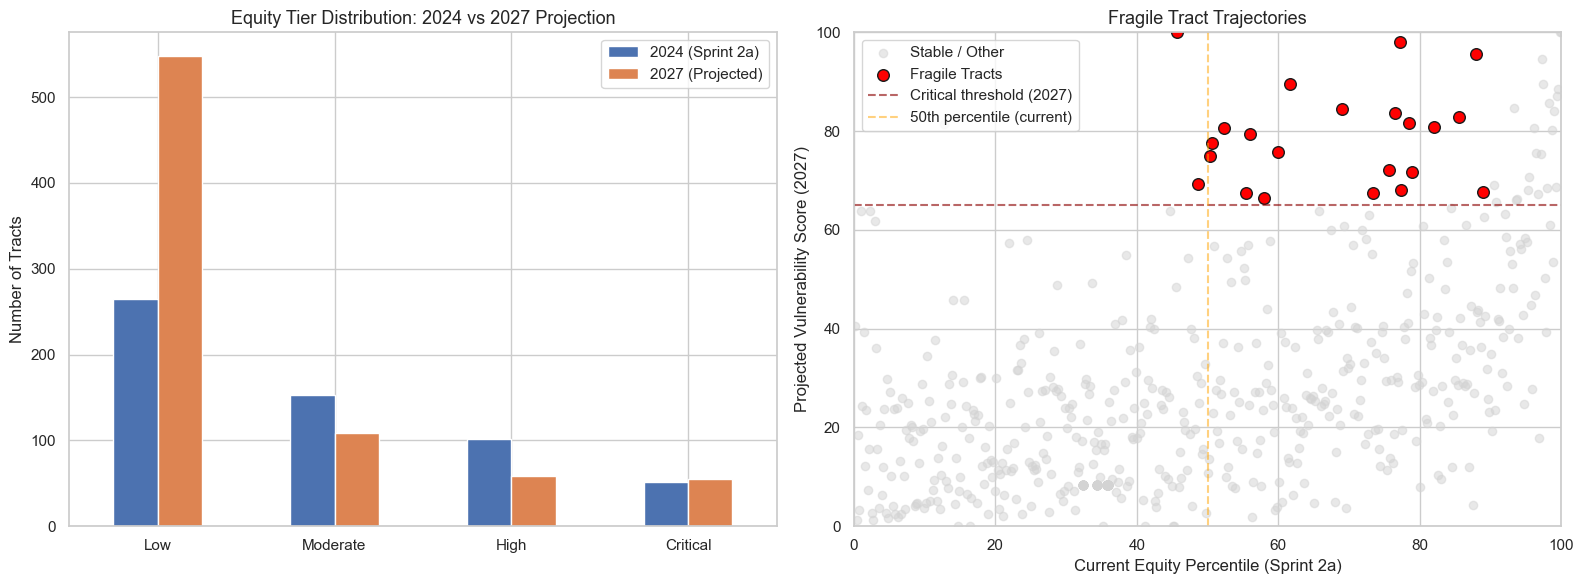

In [11]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Tier distribution shift — 2024 (Sprint 2a) vs 2027 (projected)
tier_order = ['Low', 'Moderate', 'High', 'Critical']
cat_2024 = analysis_df['equity_tier'].value_counts().reindex(tier_order).fillna(0).rename('2024 (Sprint 2a)')
cat_2027 = analysis_df['Risk_Category_2027'].value_counts().reindex(tier_order).fillna(0).rename('2027 (Projected)')
cat_shift = pd.concat([cat_2024, cat_2027], axis=1)

cat_shift.plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title('Equity Tier Distribution: 2024 vs 2027 Projection', fontsize=13)
axes[0].set_ylabel('Number of Tracts')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend()

# Plot B: Trajectory scatter — equity percentile (current) vs vulnerability score (projected)
stable = analysis_df[~analysis_df['Flag_Fragile']]
axes[1].scatter(stable['equity_percentile'], stable['Risk_Score_2027'],
                color='lightgray', alpha=0.5, label='Stable / Other')
axes[1].scatter(fragile_df['equity_percentile'], fragile_df['Risk_Score_2027'],
                color='red', s=70, edgecolor='k', label='Fragile Tracts')
axes[1].axhline(65, color='darkred', ls='--', alpha=0.6, label='Critical threshold (2027)')
axes[1].axvline(50, color='orange', ls='--', alpha=0.5, label='50th percentile (current)')
axes[1].set_title('Fragile Tract Trajectories', fontsize=13)
axes[1].set_xlabel('Current Equity Percentile (Sprint 2a)')
axes[1].set_ylabel('Projected Vulnerability Score (2027)')
axes[1].set_xlim(0, 100)
axes[1].set_ylim(0, 100)
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()


## 7. Socioeconomic Deep Dive

Profiling fragile and already-Critical tracts against the stable population to understand the structural stressors that accompany deterioration. We segment tracts into three groups using their Sprint 2a equity tier, then compare distributions of rent burden, uninsured rate, unemployment, and income trajectory.

**If fragile tracts show elevated stressors relative to stable tracts, it validates that the trend-based flags are capturing real structural vulnerability, not statistical noise.**

In [12]:
# Segment tracts by current Sprint 2a equity tier
def assign_status(row):
    if row['equity_tier'] == 'Critical':
        return '1. Already Critical'
    elif row['Flag_Fragile']:
        return '2. Fragile (Trending Critical)'
    else:
        return '3. Stable / Low-Moderate'

analysis_df['Tract_Status'] = analysis_df.apply(assign_status, axis=1)

# Summary table of key stressors by group
# mean_commute_time_min excluded — frequently contains uncleaned sentinel values
profiling_cols = [
    'median_household_income', 'rent_burden_30pct_plus',
    'unemployment_rate_pct', 'no_health_insurance_pct'
]
# Additional pass to catch any remaining negative sentinel values in these columns
for col in profiling_cols:
    if col in analysis_df.columns:
        analysis_df.loc[analysis_df[col] < 0, col] = np.nan

profile_summary = analysis_df.groupby('Tract_Status')[profiling_cols].mean().round(1)
print('--- Socioeconomic Profile by Tract Status ---')
display(profile_summary)


--- Socioeconomic Profile by Tract Status ---


,median_household_income,rent_burden_30pct_plus,unemployment_rate_pct,no_health_insurance_pct
Tract_Status,,,,
1. Already Critical,41683.6,7.9,7.9,18.4
2. Fragile (Trending Critical),42575.7,10.7,7.0,19.6
3. Stable / Low-Moderate,85174.7,8.5,4.3,12.4


### 7.1 Stressor Distributions

Boxplots compare rent burden and uninsured rate across tract groups. The violin plot shows income trajectory — a negative slope means incomes are falling. Fragile tracts sitting closer to the Critical group than the Stable group in these plots suggests the trend flags are picking up real multi-dimensional vulnerability.

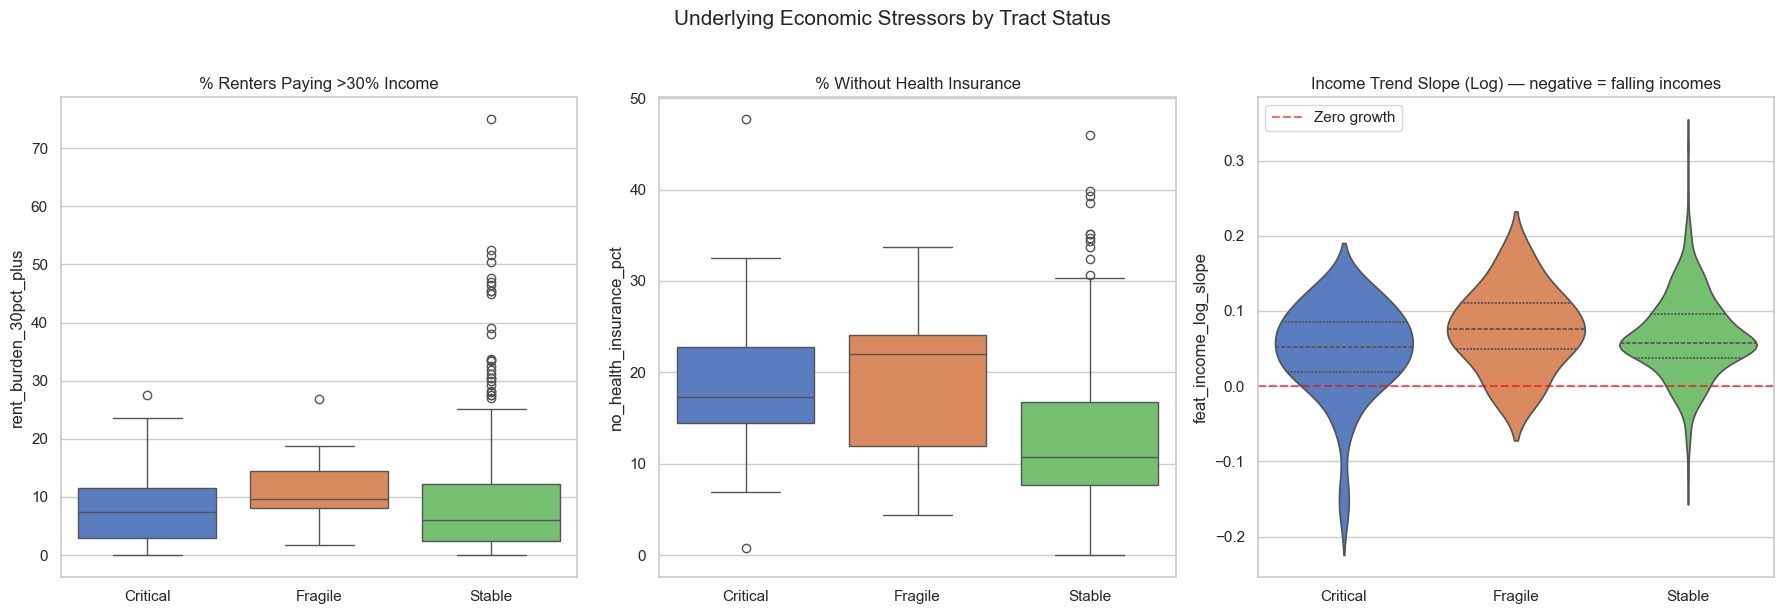

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Underlying Economic Stressors by Tract Status', fontsize=15, y=1.02)
status_order = ['1. Already Critical', '2. Fragile (Trending Critical)', '3. Stable / Low-Moderate']
labels = ['Critical', 'Fragile', 'Stable']

sns.boxplot(data=analysis_df, x='Tract_Status', y='rent_burden_30pct_plus',
            ax=axes[0], order=status_order, palette='muted')
axes[0].set_title('% Renters Paying >30% Income')
axes[0].set_xticklabels(labels)
axes[0].set_xlabel('')

sns.boxplot(data=analysis_df, x='Tract_Status', y='no_health_insurance_pct',
            ax=axes[1], order=status_order, palette='muted')
axes[1].set_title('% Without Health Insurance')
axes[1].set_xticklabels(labels)
axes[1].set_xlabel('')

sns.violinplot(data=analysis_df, x='Tract_Status', y='feat_income_log_slope',
               ax=axes[2], order=status_order, inner='quartile', palette='muted')
axes[2].axhline(0, color='red', ls='--', alpha=0.6, label='Zero growth')
axes[2].set_title('Income Trend Slope (Log) — negative = falling incomes')
axes[2].set_xticklabels(labels)
axes[2].set_xlabel('')
axes[2].legend()

plt.tight_layout()
plt.show()


### 7.2 Correlation: What drives worsening trends?

Pearson correlation between the poverty slope, vehicle access slope, and 2024 baseline characteristics. Strong correlations here tell us which current conditions are most associated with active deterioration — i.e., which tracts are both already vulnerable *and* getting worse.

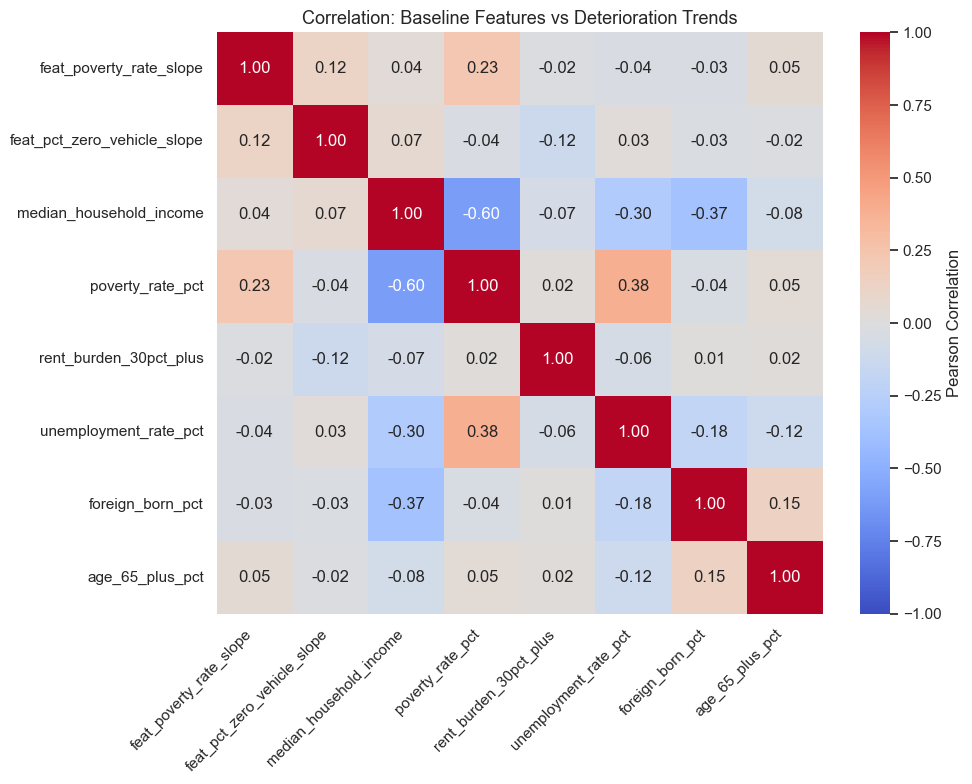

In [14]:
corr_cols = [
    'feat_poverty_rate_slope', 'feat_pct_zero_vehicle_slope',
    'median_household_income', 'poverty_rate_pct',
    'rent_burden_30pct_plus', 'unemployment_rate_pct',
    'foreign_born_pct', 'age_65_plus_pct'
]
# Only keep columns present after sentinel cleaning
corr_cols = [c for c in corr_cols if c in analysis_df.columns]

plt.figure(figsize=(10, 8))
sns.heatmap(
    analysis_df[corr_cols].corr(),
    annot=True, cmap='coolwarm', fmt='.2f',
    vmin=-1, vmax=1, center=0,
    cbar_kws={'label': 'Pearson Correlation'}
)
plt.title('Correlation: Baseline Features vs Deterioration Trends', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 8. Export

Save the full scored and flagged dataset for use in Sprint 4 dashboard alerts.

In [ ]:
output_cols = [
    'GEOID', 'NAME',
    'poverty_rate_pct', 'hh_no_vehicle_pct',
    'feat_poverty_rate_slope', 'feat_pct_zero_vehicle_slope',
    'feat_income_log_slope', 'feat_pct_seniors_slope',
    'proj_pov_2027', 'proj_veh_2027', 'Risk_Score_2027', 'Risk_Category_2027',
    'equity_tier', 'equity_priority_score', 'equity_percentile',
    'Flag_Worsening', 'Flag_Fragile', 'Tract_Status'
]
output_cols = [c for c in output_cols if c in analysis_df.columns]

analysis_df[output_cols].to_csv(OUTPUT_PATH, index=False)
print(f'✅ Exported to: {OUTPUT_PATH}')
print(f'   Shape: {analysis_df[output_cols].shape}')
print(f'   Fragile tracts: {analysis_df["Flag_Fragile"].sum()}')
print(f'   Worsening tracts: {analysis_df["Flag_Worsening"].sum()}')
